In [37]:
# ============================================================
# CELL 1: Imports, reproducibility, and output directories
# ============================================================

import os
import sys
import json
import random
import shutil
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms, models

from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )
except Exception:
    pass


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------

KAGGLE_INPUT_DIR = Path("/kaggle/input")
KAGGLE_WORKING_DIR = Path("/kaggle/working")

PROJECT_DIR = (
    KAGGLE_WORKING_DIR /
    "ATDL_Final_Evaluation"
)

TABLE_DIR = PROJECT_DIR / "tables"
PLOT_DIR = PROJECT_DIR / "plots"
RESULT_DIR = PROJECT_DIR / "results"
ABLATION_DIR = PROJECT_DIR / "ablation"
ENV_DIR = PROJECT_DIR / "environment"

for folder in [
    PROJECT_DIR,
    TABLE_DIR,
    PLOT_DIR,
    RESULT_DIR,
    ABLATION_DIR,
    ENV_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


environment_info = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "device": str(DEVICE),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    ),
    "seed": SEED,
}


with open(
    ENV_DIR / "environment.txt",
    "w"
) as f:

    for key, value in environment_info.items():
        f.write(f"{key}: {value}\n")


print("=" * 76)
print("ATDL Assignment 1 - Notebook 4")
print("Evaluation + Ablation + Final Analysis")
print("=" * 76)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU   :",
        torch.cuda.get_device_name(0)
    )

print("\nOutput:")
print(PROJECT_DIR)

ATDL Assignment 1 - Notebook 4
Evaluation + Ablation + Final Analysis
Device: cuda
GPU   : Tesla T4

Output:
/kaggle/working/ATDL_Final_Evaluation


In [38]:
# ============================================================
# CELL 2: Locate Teacher, Baseline, Student, and CIFAR-10
# ============================================================

print("Kaggle inputs:\n")

for path in sorted(
    KAGGLE_INPUT_DIR.iterdir()
):
    print(" -", path)


def find_one(filename):

    matches = list(
        KAGGLE_INPUT_DIR.rglob(
            filename
        )
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{filename} was not found."
        )

    if len(matches) > 1:
        print(
            f"\nMultiple matches found for "
            f"{filename}:"
        )

        for m in matches:
            print(" -", m)

    return matches[0]


# ------------------------------------------------------------
# Checkpoints
# ------------------------------------------------------------

TEACHER_PATH = find_one(
    "teacher.pth"
)

BASELINE_PATH = find_one(
    "baseline.pth"
)

STUDENT_TRAINING_PATH = find_one(
    "student_training.pth"
)

STUDENT_COMPACT_PATH = find_one(
    "student_ternary_compressed.pth"
)


# ------------------------------------------------------------
# Experiment roots
# ------------------------------------------------------------

TEACHER_ROOT = (
    TEACHER_PATH.parent.parent
)

BASELINE_ROOT = (
    BASELINE_PATH.parent.parent
)

STUDENT_ROOT = (
    STUDENT_TRAINING_PATH.parent.parent
)


# ------------------------------------------------------------
# Metrics/config/history
# ------------------------------------------------------------

TEACHER_METRICS_PATH = (
    TEACHER_ROOT /
    "results" /
    "teacher_final_metrics.json"
)

BASELINE_METRICS_PATH = (
    BASELINE_ROOT /
    "results" /
    "baseline_final_metrics.json"
)

STUDENT_METRICS_PATH = (
    STUDENT_ROOT /
    "results" /
    "student_final_metrics.json"
)

STUDENT_COMPRESSION_PATH = (
    STUDENT_ROOT /
    "results" /
    "compression_info.json"
)

STUDENT_CONFIG_PATH = (
    STUDENT_ROOT /
    "config" /
    "student_config.json"
)

TEACHER_HISTORY_PATH = (
    TEACHER_ROOT /
    "logs" /
    "training_history.csv"
)

BASELINE_HISTORY_PATH = (
    BASELINE_ROOT /
    "logs" /
    "training_history.csv"
)

STUDENT_HISTORY_PATH = (
    STUDENT_ROOT /
    "logs" /
    "training_history.csv"
)


# ------------------------------------------------------------
# CIFAR-10
# ------------------------------------------------------------

required_cifar_files = {
    "data_batch_1",
    "data_batch_2",
    "data_batch_3",
    "data_batch_4",
    "data_batch_5",
    "test_batch",
    "batches.meta",
}

cifar_candidates = []

for batch_file in KAGGLE_INPUT_DIR.rglob(
    "data_batch_1"
):

    candidate = batch_file.parent

    files_here = {
        p.name
        for p in candidate.iterdir()
        if p.is_file()
    }

    if required_cifar_files.issubset(
        files_here
    ):
        cifar_candidates.append(
            candidate
        )

if not cifar_candidates:
    raise FileNotFoundError(
        "CIFAR-10 batch files not found."
    )

CIFAR_BATCH_DIR = cifar_candidates[0]
CIFAR_ROOT = CIFAR_BATCH_DIR.parent


print("\nTeacher:")
print(TEACHER_PATH)

print("\nBaseline:")
print(BASELINE_PATH)

print("\nStudent training checkpoint:")
print(STUDENT_TRAINING_PATH)

print("\nStudent compact checkpoint:")
print(STUDENT_COMPACT_PATH)

print("\nCIFAR-10:")
print(CIFAR_BATCH_DIR)

Kaggle inputs:

 - /kaggle/input/datasets

Teacher:
/kaggle/input/datasets/kshitianilkumar/atdl-teacher-resnet34/ATDL_Teacher_ResNet34/checkpoints/teacher.pth

Baseline:
/kaggle/input/datasets/kshitianilkumar/baseline-resnet18/ATDL_Baseline_ResNet18/checkpoints/baseline.pth

Student training checkpoint:
/kaggle/input/datasets/kshitianilkumar/ternary-kd-qat-student/ATDL_Ternary_KD_QAT_Student/checkpoints/student_training.pth

Student compact checkpoint:
/kaggle/input/datasets/kshitianilkumar/ternary-kd-qat-student/ATDL_Ternary_KD_QAT_Student/checkpoints/student_ternary_compressed.pth

CIFAR-10:
/kaggle/input/datasets/kshitianilkumar/cifar-10/cifar/data/cifar-10-batches-py


In [39]:
# ============================================================
# CELL 2: Locate Teacher, Baseline, Student, and CIFAR-10
# ============================================================

print("Kaggle inputs:\n")

for path in sorted(
    KAGGLE_INPUT_DIR.iterdir()
):
    print(" -", path)


def find_one(filename):

    matches = list(
        KAGGLE_INPUT_DIR.rglob(
            filename
        )
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{filename} was not found."
        )

    if len(matches) > 1:
        print(
            f"\nMultiple matches found for "
            f"{filename}:"
        )

        for m in matches:
            print(" -", m)

    return matches[0]


# ------------------------------------------------------------
# Checkpoints
# ------------------------------------------------------------

TEACHER_PATH = find_one(
    "teacher.pth"
)

BASELINE_PATH = find_one(
    "baseline.pth"
)

STUDENT_TRAINING_PATH = find_one(
    "student_training.pth"
)

STUDENT_COMPACT_PATH = find_one(
    "student_ternary_compressed.pth"
)


# ------------------------------------------------------------
# Experiment roots
# ------------------------------------------------------------

TEACHER_ROOT = (
    TEACHER_PATH.parent.parent
)

BASELINE_ROOT = (
    BASELINE_PATH.parent.parent
)

STUDENT_ROOT = (
    STUDENT_TRAINING_PATH.parent.parent
)


# ------------------------------------------------------------
# Metrics/config/history
# ------------------------------------------------------------

TEACHER_METRICS_PATH = (
    TEACHER_ROOT /
    "results" /
    "teacher_final_metrics.json"
)

BASELINE_METRICS_PATH = (
    BASELINE_ROOT /
    "results" /
    "baseline_final_metrics.json"
)

STUDENT_METRICS_PATH = (
    STUDENT_ROOT /
    "results" /
    "student_final_metrics.json"
)

STUDENT_COMPRESSION_PATH = (
    STUDENT_ROOT /
    "results" /
    "compression_info.json"
)

STUDENT_CONFIG_PATH = (
    STUDENT_ROOT /
    "config" /
    "student_config.json"
)

TEACHER_HISTORY_PATH = (
    TEACHER_ROOT /
    "logs" /
    "training_history.csv"
)

BASELINE_HISTORY_PATH = (
    BASELINE_ROOT /
    "logs" /
    "training_history.csv"
)

STUDENT_HISTORY_PATH = (
    STUDENT_ROOT /
    "logs" /
    "training_history.csv"
)


# ------------------------------------------------------------
# CIFAR-10
# ------------------------------------------------------------

required_cifar_files = {
    "data_batch_1",
    "data_batch_2",
    "data_batch_3",
    "data_batch_4",
    "data_batch_5",
    "test_batch",
    "batches.meta",
}

cifar_candidates = []

for batch_file in KAGGLE_INPUT_DIR.rglob(
    "data_batch_1"
):

    candidate = batch_file.parent

    files_here = {
        p.name
        for p in candidate.iterdir()
        if p.is_file()
    }

    if required_cifar_files.issubset(
        files_here
    ):
        cifar_candidates.append(
            candidate
        )

if not cifar_candidates:
    raise FileNotFoundError(
        "CIFAR-10 batch files not found."
    )

CIFAR_BATCH_DIR = cifar_candidates[0]
CIFAR_ROOT = CIFAR_BATCH_DIR.parent


print("\nTeacher:")
print(TEACHER_PATH)

print("\nBaseline:")
print(BASELINE_PATH)

print("\nStudent training checkpoint:")
print(STUDENT_TRAINING_PATH)

print("\nStudent compact checkpoint:")
print(STUDENT_COMPACT_PATH)

print("\nCIFAR-10:")
print(CIFAR_BATCH_DIR)

Kaggle inputs:

 - /kaggle/input/datasets

Teacher:
/kaggle/input/datasets/kshitianilkumar/atdl-teacher-resnet34/ATDL_Teacher_ResNet34/checkpoints/teacher.pth

Baseline:
/kaggle/input/datasets/kshitianilkumar/baseline-resnet18/ATDL_Baseline_ResNet18/checkpoints/baseline.pth

Student training checkpoint:
/kaggle/input/datasets/kshitianilkumar/ternary-kd-qat-student/ATDL_Ternary_KD_QAT_Student/checkpoints/student_training.pth

Student compact checkpoint:
/kaggle/input/datasets/kshitianilkumar/ternary-kd-qat-student/ATDL_Ternary_KD_QAT_Student/checkpoints/student_ternary_compressed.pth

CIFAR-10:
/kaggle/input/datasets/kshitianilkumar/cifar-10/cifar/data/cifar-10-batches-py


In [40]:
# ============================================================
# CELL 3: Load all saved experiment information
# ============================================================

def load_json(path):

    with open(path, "r") as f:
        return json.load(f)


teacher_metrics = load_json(
    TEACHER_METRICS_PATH
)

baseline_metrics = load_json(
    BASELINE_METRICS_PATH
)

student_metrics = load_json(
    STUDENT_METRICS_PATH
)

compression_info = load_json(
    STUDENT_COMPRESSION_PATH
)

student_config = load_json(
    STUDENT_CONFIG_PATH
)


teacher_history = pd.read_csv(
    TEACHER_HISTORY_PATH
)

baseline_history = pd.read_csv(
    BASELINE_HISTORY_PATH
)

student_history = pd.read_csv(
    STUDENT_HISTORY_PATH
)


print("Saved primary results")
print("=" * 60)

print(
    "Teacher test accuracy :",
    teacher_metrics[
        "official_test_accuracy"
    ]
)

print(
    "Baseline test accuracy:",
    baseline_metrics[
        "official_test_accuracy"
    ]
)

print(
    "Student test accuracy :",
    student_metrics[
        "test_accuracy"
    ]
)

print(
    "\nStudent compact size:",
    student_metrics[
        "compact_checkpoint_size_mib"
    ],
    "MiB"
)

print(
    "Student sparsity:",
    student_metrics[
        "ternary_sparsity_percent"
    ],
    "%"
)

Saved primary results
Teacher test accuracy : 95.4
Baseline test accuracy: 95.49
Student test accuracy : 95.32

Student compact size: 2.8211803436279297 MiB
Student sparsity: 45.528184439817366 %


In [41]:
# ============================================================
# CELL 5: Model and ternary-layer definitions
# ============================================================

def build_cifar_resnet34(
    num_classes=10
):

    model = models.resnet34(
        weights=None,
        num_classes=num_classes
    )

    model.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    model.maxpool = nn.Identity()

    return model



def build_cifar_resnet18(
    num_classes=10
):

    model = models.resnet18(
        weights=None,
        num_classes=num_classes
    )

    model.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    model.maxpool = nn.Identity()

    return model



def ternary_quantize(
    weight,
    delta_factor=0.7
):

    reduce_dims = tuple(
        range(
            1,
            weight.dim()
        )
    )

    abs_weight = weight.abs()

    mean_abs = abs_weight.mean(
        dim=reduce_dims,
        keepdim=True
    )

    delta = (
        delta_factor *
        mean_abs
    )

    mask = (
        abs_weight > delta
    )

    numerator = (
        abs_weight * mask
    ).sum(
        dim=reduce_dims,
        keepdim=True
    )

    denominator = mask.sum(
        dim=reduce_dims,
        keepdim=True
    ).clamp_min(1)

    alpha = (
        numerator /
        denominator
    )

    codes = (
        torch.sign(weight)
        *
        mask.to(
            weight.dtype
        )
    )

    quantized = (
        alpha *
        codes
    )

    weight_ste = (
        weight +
        (
            quantized -
            weight
        ).detach()
    )

    return (
        weight_ste,
        quantized,
        codes,
        alpha,
        delta
    )



class TernaryConv2d(
    nn.Conv2d
):

    def __init__(
        self,
        *args,
        delta_factor=0.7,
        **kwargs
    ):

        super().__init__(
            *args,
            **kwargs
        )

        self.delta_factor = (
            delta_factor
        )


    def forward(
        self,
        x
    ):

        weight_ste, _, _, _, _ = (
            ternary_quantize(
                self.weight,
                self.delta_factor
            )
        )

        return F.conv2d(
            x,
            weight_ste,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups
        )


    @torch.no_grad()
    def get_quantized_weight(
        self
    ):

        _, q, codes, alpha, delta = (
            ternary_quantize(
                self.weight,
                self.delta_factor
            )
        )

        return (
            q.detach(),
            codes.detach(),
            alpha.detach(),
            delta.detach()
        )



def convert_internal_layers_to_ternary(
    module,
    prefix="",
    delta_factor=0.7
):

    for name, child in list(
        module.named_children()
    ):

        full_name = (
            f"{prefix}.{name}"
            if prefix
            else name
        )

        if isinstance(
            child,
            nn.Conv2d
        ):

            # Keep first conv FP32
            if full_name == "conv1":
                continue

            replacement = TernaryConv2d(

                child.in_channels,
                child.out_channels,

                kernel_size=
                    child.kernel_size,

                stride=
                    child.stride,

                padding=
                    child.padding,

                dilation=
                    child.dilation,

                groups=
                    child.groups,

                bias=(
                    child.bias
                    is not None
                ),

                padding_mode=
                    child.padding_mode,

                delta_factor=
                    delta_factor
            )

            setattr(
                module,
                name,
                replacement
            )

        else:

            convert_internal_layers_to_ternary(
                child,
                full_name,
                delta_factor
            )



def unpack_ternary_codes(
    packed,
    numel
):

    p = (
        packed
        .cpu()
        .to(torch.int64)
    )

    values = torch.stack([

        p & 0b11,

        (p >> 2) & 0b11,

        (p >> 4) & 0b11,

        (p >> 6) & 0b11,

    ], dim=1).reshape(-1)

    values = values[:numel]

    if torch.any(
        values > 2
    ):
        raise ValueError(
            "Invalid ternary code."
        )

    return (
        values.to(torch.int8)
        -
        1
    )


print(
    "Architecture and ternary helpers ready."
)

Architecture and ternary helpers ready.


In [42]:
# ============================================================
# CELL 6: Load primary checkpoints
# ============================================================

teacher_ckpt = torch.load(
    TEACHER_PATH,
    map_location="cpu",
    weights_only=False
)

baseline_ckpt = torch.load(
    BASELINE_PATH,
    map_location="cpu",
    weights_only=False
)

student_ckpt = torch.load(
    STUDENT_TRAINING_PATH,
    map_location="cpu",
    weights_only=False
)

compact_ckpt = torch.load(
    STUDENT_COMPACT_PATH,
    map_location="cpu",
    weights_only=False
)


teacher = build_cifar_resnet34()

teacher.load_state_dict(
    teacher_ckpt[
        "model_state_dict"
    ]
)


baseline = build_cifar_resnet18()

baseline.load_state_dict(
    baseline_ckpt[
        "model_state_dict"
    ]
)


student = build_cifar_resnet18()

convert_internal_layers_to_ternary(
    student,
    delta_factor=
        student_config[
            "delta_factor"
        ]
)

student.load_state_dict(
    student_ckpt[
        "model_state_dict"
    ]
)


print("Teacher checkpoint: PASS")
print("Baseline checkpoint: PASS")
print("Student checkpoint: PASS")

print(
    "Compact format:",
    compact_ckpt["format"]
)

assert (
    compact_ckpt["format"]
    ==
    "ATDL_PACKED_TERNARY_V1"
)

Teacher checkpoint: PASS
Baseline checkpoint: PASS
Student checkpoint: PASS
Compact format: ATDL_PACKED_TERNARY_V1


In [43]:
# ============================================================
# CELL 7: Compute parameters, zeros, sparsity, and sizes
# ============================================================

def parameter_count(model):

    return sum(
        p.numel()
        for p in model.parameters()
    )


def conv_linear_weight_stats_from_state(
    state
):

    total = 0
    zeros = 0

    for key, tensor in state.items():

        # Conv/Linear weights have >= 2 dims.
        # BN scale vectors are 1D and are excluded.
        if (
            key.endswith(".weight")
            and
            tensor.dim() >= 2
        ):

            total += tensor.numel()

            zeros += (
                tensor == 0
            ).sum().item()

    return (
        total,
        zeros,
        100.0 * zeros / total
    )


def state_tensor_bytes(
    state
):

    return sum(
        tensor.numel()
        *
        tensor.element_size()

        for tensor
        in state.values()
    )


# ------------------------------------------------------------
# Teacher
# ------------------------------------------------------------

teacher_params = parameter_count(
    teacher
)

(
    teacher_weight_count,
    teacher_zero_weights,
    teacher_sparsity
) = conv_linear_weight_stats_from_state(

    teacher_ckpt[
        "model_state_dict"
    ]
)


# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

baseline_params = parameter_count(
    baseline
)

(
    baseline_weight_count,
    baseline_zero_weights,
    baseline_sparsity
) = conv_linear_weight_stats_from_state(

    baseline_ckpt[
        "model_state_dict"
    ]
)


# ------------------------------------------------------------
# Student compact ternary portion
# ------------------------------------------------------------

student_ternary_count = 0
student_ternary_zero = 0

for (
    layer_name,
    info
) in compact_ckpt[
    "ternary_layers"
].items():

    codes = unpack_ternary_codes(

        info[
            "packed_codes"
        ],

        info[
            "numel"
        ]
    )

    student_ternary_count += (
        codes.numel()
    )

    student_ternary_zero += (
        codes == 0
    ).sum().item()


# FP32 Conv/FC exceptions in compact checkpoint
student_fp32_weight_count = 0
student_fp32_zero = 0

for key, tensor in compact_ckpt[
    "fp32_state"
].items():

    if (
        key.endswith(".weight")
        and
        tensor.dim() >= 2
    ):

        student_fp32_weight_count += (
            tensor.numel()
        )

        student_fp32_zero += (
            tensor == 0
        ).sum().item()


student_weight_count = (

    student_ternary_count
    +
    student_fp32_weight_count
)

student_zero_weights = (

    student_ternary_zero
    +
    student_fp32_zero
)

student_all_weight_sparsity = (

    100.0
    *
    student_zero_weights
    /
    student_weight_count
)

student_ternary_sparsity = (

    100.0
    *
    student_ternary_zero
    /
    student_ternary_count
)


student_params = parameter_count(
    student
)


# ------------------------------------------------------------
# Actual file sizes
# ------------------------------------------------------------

teacher_file_bytes = (
    TEACHER_PATH.stat().st_size
)

baseline_file_bytes = (
    BASELINE_PATH.stat().st_size
)

student_compact_bytes = (
    STUDENT_COMPACT_PATH.stat().st_size
)

student_training_bytes = (
    STUDENT_TRAINING_PATH.stat().st_size
)


def mib(value):

    return (
        value /
        (1024 ** 2)
    )


# ------------------------------------------------------------
# Theoretical state tensor storage
# ------------------------------------------------------------

teacher_state_bytes = (
    state_tensor_bytes(
        teacher_ckpt[
            "model_state_dict"
        ]
    )
)

baseline_state_bytes = (
    state_tensor_bytes(
        baseline_ckpt[
            "model_state_dict"
        ]
    )
)


student_theoretical_bytes = (

    compression_info[
        "theoretical_compact_bytes"
    ]
)


print("Teacher parameters :", f"{teacher_params:,}")
print("Baseline parameters:", f"{baseline_params:,}")
print("Student parameters :", f"{student_params:,}")

print(
    "\nStudent ternary weights:",
    f"{student_ternary_count:,}"
)

print(
    "Student ternary zeros:",
    f"{student_ternary_zero:,}"
)

print(
    "Student ternary sparsity:",
    f"{student_ternary_sparsity:.2f}%"
)

print(
    "\nActual checkpoint sizes:"
)

print(
    "Teacher :",
    f"{mib(teacher_file_bytes):.2f} MiB"
)

print(
    "Baseline:",
    f"{mib(baseline_file_bytes):.2f} MiB"
)

print(
    "Student compact:",
    f"{mib(student_compact_bytes):.2f} MiB"
)

Teacher parameters : 21,282,122
Baseline parameters: 11,173,962
Student parameters : 11,173,962

Student ternary weights: 11,157,504
Student ternary zeros: 5,079,809
Student ternary sparsity: 45.53%

Actual checkpoint sizes:
Teacher : 81.31 MiB
Baseline: 42.70 MiB
Student compact: 2.82 MiB


In [44]:
# ============================================================
# CELL 8: Final Teacher vs Baseline vs Student table
# ============================================================

teacher_accuracy = float(
    teacher_metrics[
        "official_test_accuracy"
    ]
)

baseline_accuracy = float(
    baseline_metrics[
        "official_test_accuracy"
    ]
)

student_accuracy = float(
    student_metrics[
        "test_accuracy"
    ]
)


comparison_df = pd.DataFrame([

    {
        "Model":
            "ResNet34 FP32 Teacher",

        "Architecture":
            "ResNet34",

        "Weight Type":
            "FP32",

        "Test Accuracy (%)":
            teacher_accuracy,

        "Parameters":
            teacher_params,

        "Conv/FC Weights":
            teacher_weight_count,

        "Zero Conv/FC Weights":
            teacher_zero_weights,

        "Weight Sparsity (%)":
            teacher_sparsity,

        "Actual Checkpoint (MiB)":
            mib(
                teacher_file_bytes
            ),

        "Theoretical Tensor Storage (MiB)":
            mib(
                teacher_state_bytes
            ),

        "Compression vs FP32 Baseline":
            baseline_file_bytes /
            teacher_file_bytes,

        "Teacher Accuracy Gap (pp)":
            0.0,
    },

    {
        "Model":
            "ResNet18 FP32 Baseline",

        "Architecture":
            "ResNet18",

        "Weight Type":
            "FP32",

        "Test Accuracy (%)":
            baseline_accuracy,

        "Parameters":
            baseline_params,

        "Conv/FC Weights":
            baseline_weight_count,

        "Zero Conv/FC Weights":
            baseline_zero_weights,

        "Weight Sparsity (%)":
            baseline_sparsity,

        "Actual Checkpoint (MiB)":
            mib(
                baseline_file_bytes
            ),

        "Theoretical Tensor Storage (MiB)":
            mib(
                baseline_state_bytes
            ),

        "Compression vs FP32 Baseline":
            1.0,

        "Teacher Accuracy Gap (pp)":
            teacher_accuracy
            -
            baseline_accuracy,
    },

    {
        "Model":
            "ResNet18 Ternary KD+QAT",

        "Architecture":
            "ResNet18",

        "Weight Type":
            "Ternary internal Conv + FP32 conv1/fc",

        "Test Accuracy (%)":
            student_accuracy,

        "Parameters":
            student_params,

        "Conv/FC Weights":
            student_weight_count,

        "Zero Conv/FC Weights":
            student_zero_weights,

        "Weight Sparsity (%)":
            student_all_weight_sparsity,

        "Actual Checkpoint (MiB)":
            mib(
                student_compact_bytes
            ),

        "Theoretical Tensor Storage (MiB)":
            mib(
                student_theoretical_bytes
            ),

        "Compression vs FP32 Baseline":
            baseline_file_bytes /
            student_compact_bytes,

        "Teacher Accuracy Gap (pp)":
            teacher_accuracy
            -
            student_accuracy,
    }
])


pd.set_option(
    "display.max_columns",
    None
)

display(
    comparison_df
)


comparison_df.to_csv(
    TABLE_DIR /
    "final_model_comparison.csv",
    index=False
)


with open(
    RESULT_DIR /
    "final_model_comparison.json",
    "w"
) as f:

    json.dump(
        comparison_df.to_dict(
            orient="records"
        ),
        f,
        indent=4
    )


print(
    "\nSaved final comparison table."
)

,Model,Architecture,Weight Type,Test Accuracy (%),Parameters,Conv/FC Weights,Zero Conv/FC Weights,Weight Sparsity (%),Actual Checkpoint (MiB),Theoretical Tensor Storage (MiB),Compression vs FP32 Baseline,Teacher Accuracy Gap (pp)
0,ResNet34 FP32 Teacher,ResNet34,FP32,95.40,21282122,21265088,0,0.000000,81.312816,81.250069,0.525113,0.00
1,ResNet18 FP32 Baseline,ResNet18,FP32,95.49,11173962,11164352,0,0.000000,42.698436,42.662056,1.000000,-0.09
2,ResNet18 Ternary KD+QAT,ResNet18,Ternary internal Conv + FP32 conv1/fc,95.32,11173962,11164352,5079809,45.500258,2.821180,2.777779,15.134954,0.08



Saved final comparison table.


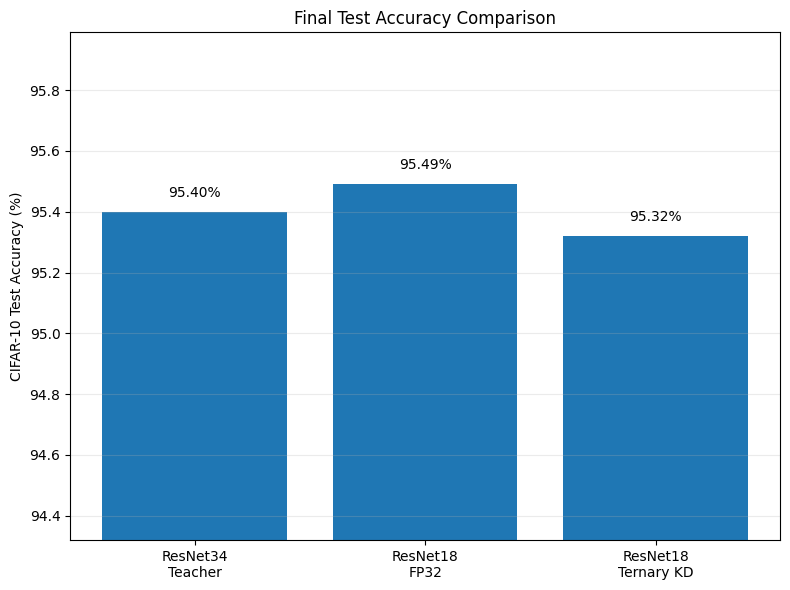

In [45]:
# ============================================================
# CELL 9: Final accuracy comparison
# ============================================================

model_names = [
    "ResNet34\nTeacher",
    "ResNet18\nFP32",
    "ResNet18\nTernary KD"
]

accuracies = [
    teacher_accuracy,
    baseline_accuracy,
    student_accuracy
]


plt.figure(
    figsize=(8, 6)
)

bars = plt.bar(
    model_names,
    accuracies
)

plt.ylabel(
    "CIFAR-10 Test Accuracy (%)"
)

plt.title(
    "Final Test Accuracy Comparison"
)

plt.ylim(
    min(accuracies) - 1.0,
    max(accuracies) + 0.5
)

plt.grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(
    bars,
    accuracies
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.05,

        f"{value:.2f}%",

        ha="center"
    )


plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "final_accuracy_comparison.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

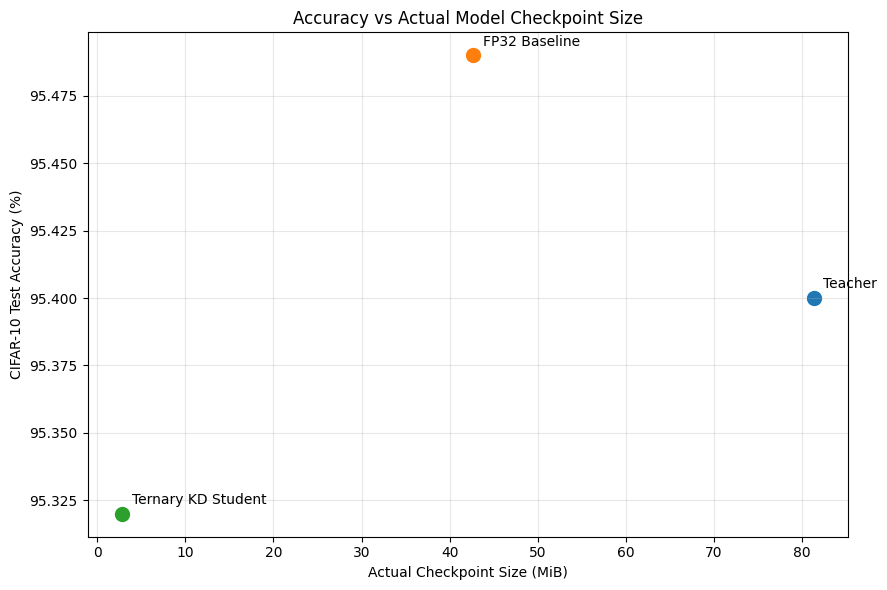

In [46]:
# ============================================================
# CELL 10: Accuracy vs actual checkpoint size
# ============================================================

sizes = [

    mib(
        teacher_file_bytes
    ),

    mib(
        baseline_file_bytes
    ),

    mib(
        student_compact_bytes
    )
]


labels = [
    "Teacher",
    "FP32 Baseline",
    "Ternary KD Student"
]


plt.figure(
    figsize=(9, 6)
)


for x, y, label in zip(
    sizes,
    accuracies,
    labels
):

    plt.scatter(
        x,
        y,
        s=100
    )

    plt.annotate(
        label,

        (
            x,
            y
        ),

        xytext=(
            7,
            7
        ),

        textcoords=
            "offset points"
    )


plt.xlabel(
    "Actual Checkpoint Size (MiB)"
)

plt.ylabel(
    "CIFAR-10 Test Accuracy (%)"
)

plt.title(
    "Accuracy vs Actual Model Checkpoint Size"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "accuracy_vs_checkpoint_size.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

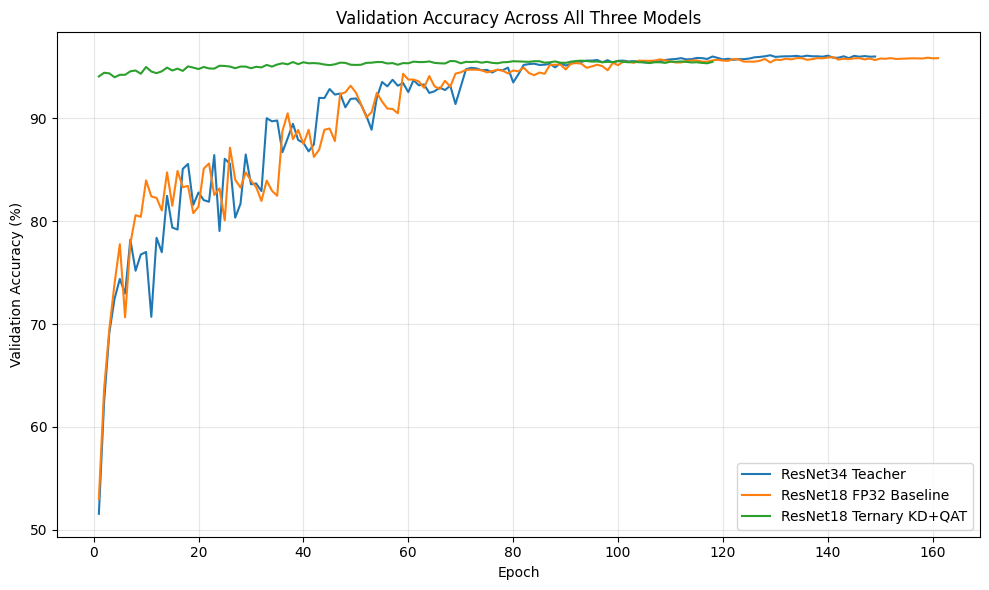

In [47]:
# ============================================================
# CELL 11: Combined validation accuracy curves
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    teacher_history["epoch"],
    teacher_history[
        "val_accuracy"
    ],
    label="ResNet34 Teacher"
)


plt.plot(
    baseline_history["epoch"],
    baseline_history[
        "val_accuracy"
    ],
    label="ResNet18 FP32 Baseline"
)


plt.plot(
    student_history["epoch"],
    student_history[
        "val_accuracy"
    ],
    label="ResNet18 Ternary KD+QAT"
)


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy Across All Three Models"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "combined_validation_accuracy.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

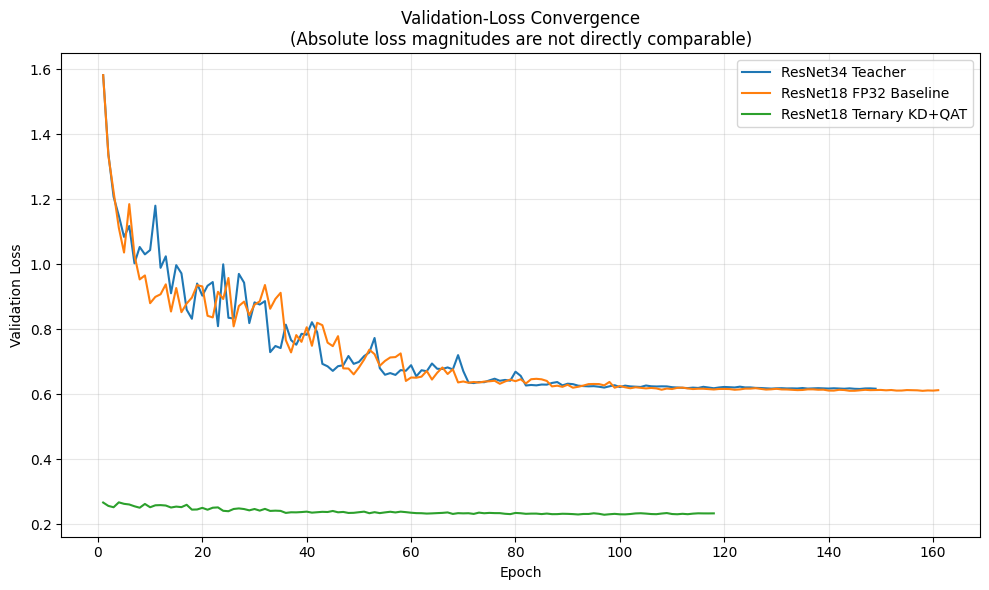

In [48]:
# ============================================================
# CELL 12: Validation loss convergence
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    teacher_history["epoch"],
    teacher_history["val_loss"],
    label="ResNet34 Teacher"
)


plt.plot(
    baseline_history["epoch"],
    baseline_history["val_loss"],
    label="ResNet18 FP32 Baseline"
)


plt.plot(
    student_history["epoch"],
    student_history["val_loss"],
    label="ResNet18 Ternary KD+QAT"
)


plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Validation-Loss Convergence\n"
    "(Absolute loss magnitudes are not directly comparable)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "combined_validation_loss_convergence.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

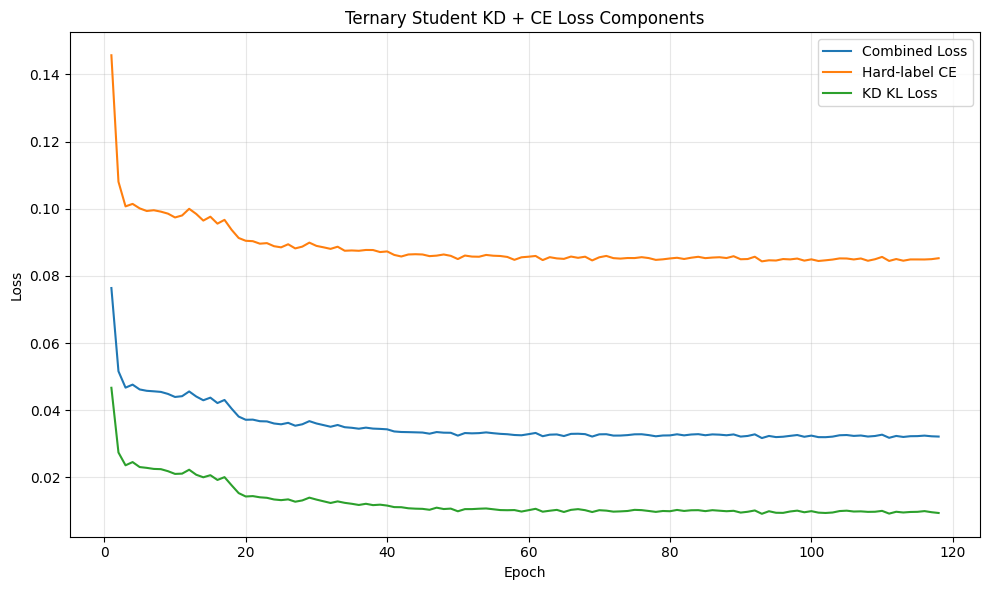

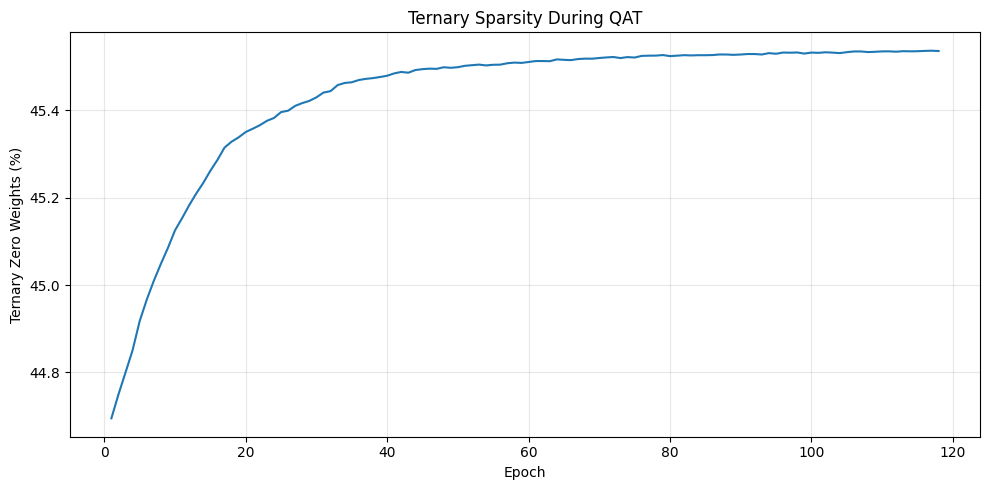

In [49]:
# ============================================================
# CELL 13: KD/QAT loss components and sparsity
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    student_history["epoch"],
    student_history[
        "train_total_loss"
    ],
    label="Combined Loss"
)


plt.plot(
    student_history["epoch"],
    student_history[
        "train_ce_loss"
    ],
    label="Hard-label CE"
)


plt.plot(
    student_history["epoch"],
    student_history[
        "train_kd_loss"
    ],
    label="KD KL Loss"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Ternary Student KD + CE Loss Components"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "student_kd_loss_components.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(10, 5)
)


plt.plot(
    student_history["epoch"],
    student_history[
        "sparsity_percent"
    ]
)


plt.xlabel("Epoch")
plt.ylabel("Ternary Zero Weights (%)")

plt.title(
    "Ternary Sparsity During QAT"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "student_qat_sparsity.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

Representative layer: layer4.0.conv2
Output channel: 0
Alpha: 0.004544945899397135
Allowed channel values: [-0.004544945899397135, 0.0, 0.004544945899397135]


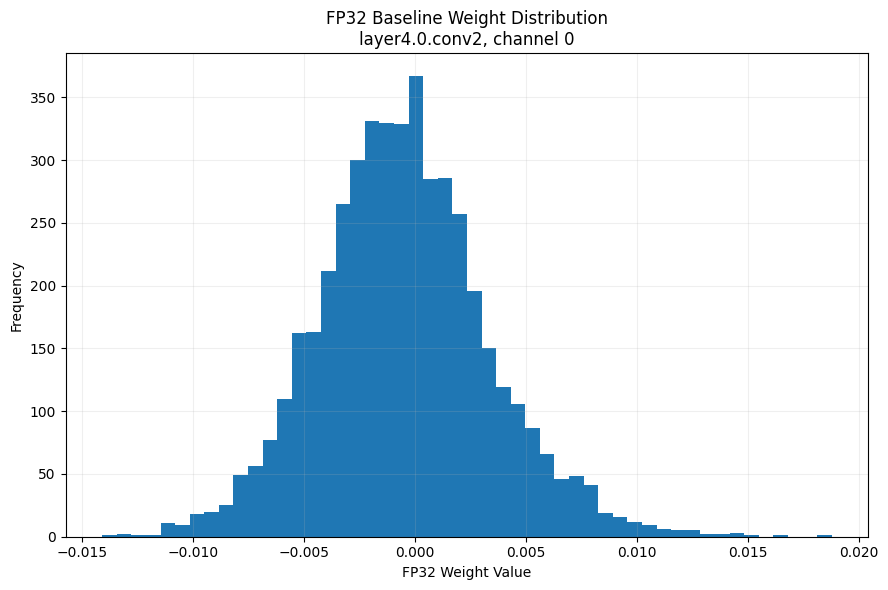

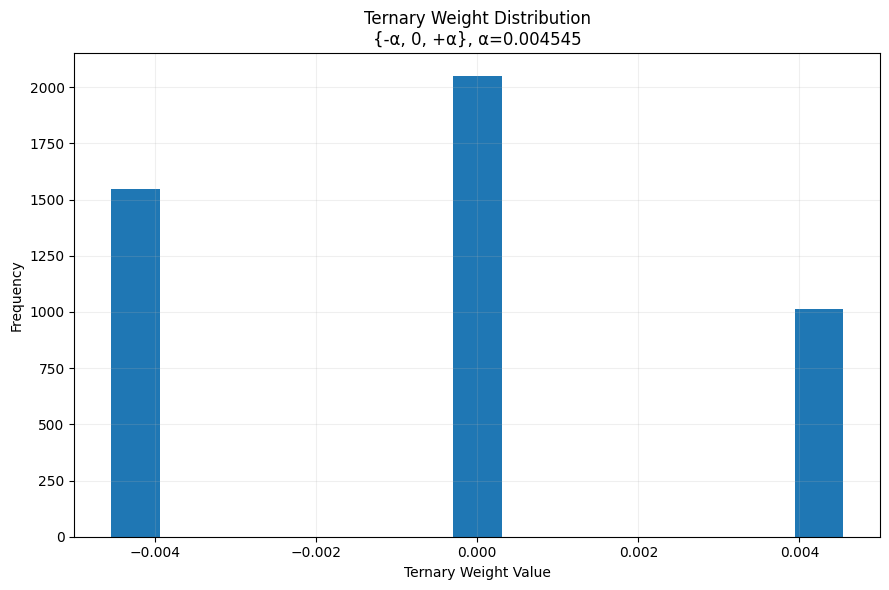

In [50]:
# ============================================================
# CELL 14: FP32 vs ternary weight-distribution histograms
# ============================================================

representative_layer = None
representative_channel = None
representative_codes = None
representative_alpha = None


# Prefer a large internal layer
candidate_layers = sorted(

    compact_ckpt[
        "ternary_layers"
    ].items(),

    key=lambda item:
        item[1]["numel"],

    reverse=True
)


for (
    layer_name,
    info
) in candidate_layers:

    codes = unpack_ternary_codes(

        info[
            "packed_codes"
        ],

        info[
            "numel"
        ]
    ).reshape(
        info[
            "shape"
        ]
    )


    alpha = info[
        "alpha"
    ].reshape(-1)


    for channel_id in range(
        codes.shape[0]
    ):

        unique = set(
            codes[
                channel_id
            ]
            .reshape(-1)
            .tolist()
        )

        if {
            -1,
            0,
            1
        }.issubset(
            unique
        ):

            representative_layer = (
                layer_name
            )

            representative_channel = (
                channel_id
            )

            representative_codes = (
                codes[
                    channel_id
                ].clone()
            )

            representative_alpha = (
                float(
                    alpha[
                        channel_id
                    ].item()
                )
            )

            break


    if (
        representative_layer
        is not None
    ):
        break


assert (
    representative_layer
    is not None
)


baseline_weight_key = (
    representative_layer
    +
    ".weight"
)


fp32_channel = (

    baseline_ckpt[
        "model_state_dict"
    ][
        baseline_weight_key
    ][
        representative_channel
    ]

    .reshape(-1)
    .numpy()
)


ternary_values = (

    representative_codes
    .to(
        torch.float32
    )

    *
    representative_alpha
)

ternary_values = (
    ternary_values
    .reshape(-1)
    .numpy()
)


print(
    "Representative layer:",
    representative_layer
)

print(
    "Output channel:",
    representative_channel
)

print(
    "Alpha:",
    representative_alpha
)

print(
    "Allowed channel values:",
    [
        -representative_alpha,
        0.0,
        representative_alpha
    ]
)


# ------------------------------------------------------------
# FP32 histogram
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    fp32_channel,
    bins=50
)

plt.xlabel(
    "FP32 Weight Value"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    f"FP32 Baseline Weight Distribution\n"
    f"{representative_layer}, "
    f"channel {representative_channel}"
)

plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "fp32_weight_histogram.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Ternary histogram
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    ternary_values,
    bins=15
)

plt.xlabel(
    "Ternary Weight Value"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    f"Ternary Weight Distribution\n"
    f"{{-α, 0, +α}}, α={representative_alpha:.6f}"
)

plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "ternary_weight_histogram.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

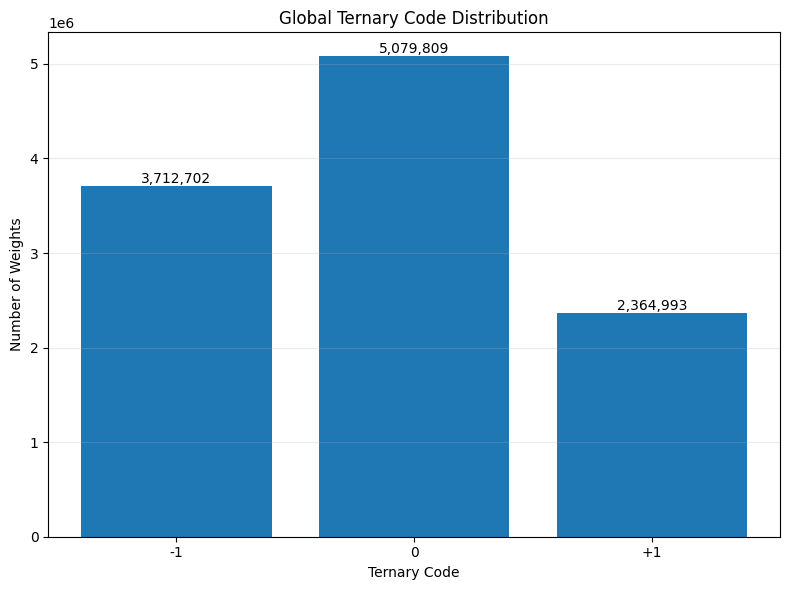

Negative: 3,712,702
Zero    : 5,079,809
Positive: 2,364,993


In [51]:
# ============================================================
# CELL 15: Global {-1, 0, +1} ternary-code distribution
# ============================================================

negative_count = 0
zero_count = 0
positive_count = 0


for (
    layer_name,
    info
) in compact_ckpt[
    "ternary_layers"
].items():

    codes = unpack_ternary_codes(

        info[
            "packed_codes"
        ],

        info[
            "numel"
        ]
    )


    negative_count += (
        codes == -1
    ).sum().item()

    zero_count += (
        codes == 0
    ).sum().item()

    positive_count += (
        codes == 1
    ).sum().item()


code_counts = [
    negative_count,
    zero_count,
    positive_count
]


plt.figure(
    figsize=(8, 6)
)

bars = plt.bar(
    ["-1", "0", "+1"],
    code_counts
)


plt.xlabel(
    "Ternary Code"
)

plt.ylabel(
    "Number of Weights"
)

plt.title(
    "Global Ternary Code Distribution"
)

plt.grid(
    axis="y",
    alpha=0.25
)


for bar, count in zip(
    bars,
    code_counts
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        count,

        f"{count:,}",

        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "ternary_code_distribution.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


print(
    "Negative:",
    f"{negative_count:,}"
)

print(
    "Zero    :",
    f"{zero_count:,}"
)

print(
    "Positive:",
    f"{positive_count:,}"
)

,Layer,Weights,Zero Weights,Sparsity (%)
0,layer1.0.conv1,36864,22705,61.591254
1,layer1.0.conv2,36864,18233,49.460178
2,layer1.1.conv1,36864,18470,50.103082
3,layer1.1.conv2,36864,16982,46.066623
4,layer2.0.conv1,73728,32303,43.813748
5,layer2.0.conv2,147456,64229,43.558078
6,layer2.0.downsample.0,8192,3652,44.580078
7,layer2.1.conv1,147456,64999,44.080268
8,layer2.1.conv2,147456,64189,43.530952
9,layer3.0.conv1,294912,128661,43.626912


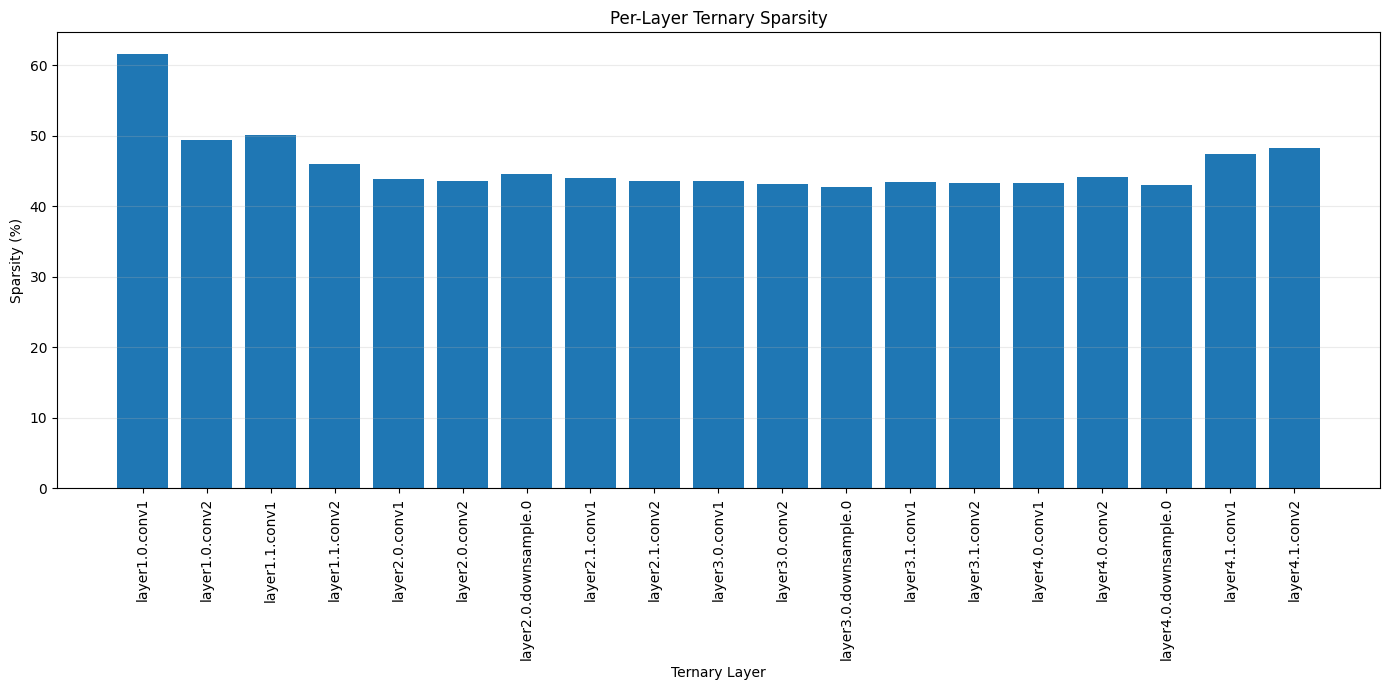

In [52]:
# ============================================================
# CELL 16: Per-layer ternary sparsity
# ============================================================

layer_sparsity = []


for (
    layer_name,
    info
) in compact_ckpt[
    "ternary_layers"
].items():

    codes = unpack_ternary_codes(

        info[
            "packed_codes"
        ],

        info[
            "numel"
        ]
    )


    zeros = (
        codes == 0
    ).sum().item()

    count = (
        codes.numel()
    )


    layer_sparsity.append({

        "Layer":
            layer_name,

        "Weights":
            count,

        "Zero Weights":
            zeros,

        "Sparsity (%)":
            100.0
            *
            zeros
            /
            count
    })


layer_sparsity_df = pd.DataFrame(
    layer_sparsity
)


layer_sparsity_df.to_csv(
    TABLE_DIR /
    "per_layer_ternary_sparsity.csv",
    index=False
)


display(
    layer_sparsity_df
)


plt.figure(
    figsize=(14, 7)
)


plt.bar(
    layer_sparsity_df[
        "Layer"
    ],

    layer_sparsity_df[
        "Sparsity (%)"
    ]
)


plt.xticks(
    rotation=90
)

plt.ylabel(
    "Sparsity (%)"
)

plt.xlabel(
    "Ternary Layer"
)

plt.title(
    "Per-Layer Ternary Sparsity"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "per_layer_sparsity.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [53]:
# ============================================================
# CELL 17: Compression analysis
# ============================================================

actual_student_compression = (

    baseline_file_bytes
    /
    student_compact_bytes
)


theoretical_student_compression = (

    baseline_state_bytes
    /
    student_theoretical_bytes
)


compression_analysis = {

    "teacher_checkpoint_mib":
        mib(
            teacher_file_bytes
        ),

    "baseline_checkpoint_mib":
        mib(
            baseline_file_bytes
        ),

    "student_training_checkpoint_mib":
        mib(
            student_training_bytes
        ),

    "student_compact_checkpoint_mib":
        mib(
            student_compact_bytes
        ),

    "actual_student_compression_vs_baseline":
        actual_student_compression,

    "baseline_theoretical_tensor_storage_mib":
        mib(
            baseline_state_bytes
        ),

    "student_theoretical_compact_storage_mib":
        mib(
            student_theoretical_bytes
        ),

    "theoretical_student_compression_vs_baseline":
        theoretical_student_compression,

    "ternary_weight_count":
        student_ternary_count,

    "ternary_zero_weight_count":
        student_ternary_zero,

    "ternary_sparsity_percent":
        student_ternary_sparsity,

    "interpretation": (
        "Actual checkpoint compression measures "
        "serialized .pth sizes. Theoretical compression "
        "uses packed ternary codes, alpha scales and "
        "remaining FP32 tensors. Parameter count is "
        "different from storage size."
    )
}


with open(
    RESULT_DIR /
    "compression_analysis.json",
    "w"
) as f:

    json.dump(
        compression_analysis,
        f,
        indent=4
    )


print(
    json.dumps(
        compression_analysis,
        indent=4
    )
)

{
    "teacher_checkpoint_mib": 81.31281566619873,
    "baseline_checkpoint_mib": 42.69843578338623,
    "student_training_checkpoint_mib": 42.69953441619873,
    "student_compact_checkpoint_mib": 2.8211803436279297,
    "actual_student_compression_vs_baseline": 15.134954374620971,
    "baseline_theoretical_tensor_storage_mib": 42.66205596923828,
    "student_theoretical_compact_storage_mib": 2.7777786254882812,
    "theoretical_student_compression_vs_baseline": 15.358335461933757,
    "ternary_weight_count": 11157504,
    "ternary_zero_weight_count": 5079809,
    "ternary_sparsity_percent": 45.528184439817366,
    "interpretation": "Actual checkpoint compression measures serialized .pth sizes. Theoretical compression uses packed ternary codes, alpha scales and remaining FP32 tensors. Parameter count is different from storage size."
}


In [54]:
# ============================================================
# CELL 18: Ablation data pipeline
# ============================================================

CIFAR_MEAN = tuple(
    student_config[
        "normalization_mean"
    ]
)

CIFAR_STD = tuple(
    student_config[
        "normalization_std"
    ]
)

BATCH_SIZE = (
    student_config[
        "batch_size"
    ]
)

NUM_WORKERS = min(
    4,
    os.cpu_count() or 2
)


class Cutout:

    def __init__(
        self,
        size=8
    ):

        self.size = size


    def __call__(
        self,
        tensor
    ):

        _, height, width = (
            tensor.shape
        )

        cy = torch.randint(
            0,
            height,
            (1,)
        ).item()

        cx = torch.randint(
            0,
            width,
            (1,)
        ).item()

        half = (
            self.size // 2
        )

        y1 = max(
            0,
            cy - half
        )

        y2 = min(
            height,
            cy + half
        )

        x1 = max(
            0,
            cx - half
        )

        x2 = min(
            width,
            cx + half
        )

        tensor = tensor.clone()

        tensor[
            :,
            y1:y2,
            x1:x2
        ] = 0.0

        return tensor


train_transform = transforms.Compose([

    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ToTensor(),

    Cutout(
        size=student_config[
            "cutout_size"
        ]
    ),

    transforms.Normalize(
        CIFAR_MEAN,
        CIFAR_STD
    ),
])


eval_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR_MEAN,
        CIFAR_STD
    ),
])

# ------------------------------------------------------------
# Load the exact original train/validation split
# ------------------------------------------------------------

split_path = (
    TEACHER_ROOT
    / "config"
    / "cifar10_split_indices.npz"
)

split_data = np.load(
    split_path
)

reference_train = split_data[
    "train_indices"
]

reference_val = split_data[
    "val_indices"
]


assert len(reference_train) == 45000
assert len(reference_val) == 5000

assert len(
    np.intersect1d(
        reference_train,
        reference_val
    )
) == 0


print(
    "Ablation training indices:",
    len(reference_train)
)

print(
    "Ablation validation indices:",
    len(reference_val)
)


base_train_dataset = datasets.CIFAR10(

    root=str(
        CIFAR_ROOT
    ),

    train=True,

    download=False,

    transform=None
)


class CIFARSubset(Dataset):

    def __init__(
        self,
        base_dataset,
        indices,
        transform=None
    ):

        self.base_dataset = (
            base_dataset
        )

        self.indices = np.asarray(
            indices
        )

        self.transform = transform


    def __len__(self):

        return len(
            self.indices
        )


    def __getitem__(
        self,
        idx
    ):

        original_idx = (
            self.indices[idx]
        )

        image = (
            self.base_dataset.data[
                original_idx
            ]
        )

        label = (
            self.base_dataset.targets[
                original_idx
            ]
        )

        image = Image.fromarray(
            image
        )

        if self.transform is not None:

            image = self.transform(
                image
            )

        return image, label


ablation_train_dataset = CIFARSubset(

    base_train_dataset,

    reference_train,

    train_transform
)


ablation_val_dataset = CIFARSubset(

    base_train_dataset,

    reference_val,

    eval_transform
)


def seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        %
        (2 ** 32)
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


generator = torch.Generator()

generator.manual_seed(
    SEED
)


ablation_train_loader = DataLoader(

    ablation_train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    persistent_workers=(
        NUM_WORKERS > 0
    ),

    worker_init_fn=seed_worker,

    generator=generator
)


ablation_val_loader = DataLoader(

    ablation_val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    persistent_workers=(
        NUM_WORKERS > 0
    )
)


print(
    "Ablation train samples:",
    len(ablation_train_dataset)
)

print(
    "Ablation val samples:",
    len(ablation_val_dataset)
)

Ablation training indices: 45000
Ablation validation indices: 5000
Ablation train samples: 45000
Ablation val samples: 5000


In [55]:
# ============================================================
# CELL 19: Prepare ablation model
# ============================================================

# Reset seeds before controlled experiment
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        SEED
    )


# ------------------------------------------------------------
# Frozen teacher
# ------------------------------------------------------------

ablation_teacher = (
    build_cifar_resnet34()
)

ablation_teacher.load_state_dict(

    teacher_ckpt[
        "model_state_dict"
    ]
)

ablation_teacher = (
    ablation_teacher.to(
        DEVICE
    )
)

ablation_teacher.eval()


for p in (
    ablation_teacher.parameters()
):
    p.requires_grad = False


assert sum(
    p.numel()
    for p
    in ablation_teacher.parameters()
    if p.requires_grad
) == 0


# ------------------------------------------------------------
# Ternary student initialized from SAME FP32 baseline
# ------------------------------------------------------------

ablation_student = (
    build_cifar_resnet18()
)


convert_internal_layers_to_ternary(

    ablation_student,

    delta_factor=
        student_config[
            "delta_factor"
        ]
)


ablation_student.load_state_dict(

    baseline_ckpt[
        "model_state_dict"
    ],

    strict=True
)


ablation_student = (
    ablation_student.to(
        DEVICE
    )
)


# ------------------------------------------------------------
# Only changed variable
# ------------------------------------------------------------

MAIN_T = float(
    student_config[
        "temperature"
    ]
)

ABLATION_T = 2.0

KD_LAMBDA = float(
    student_config[
        "kd_lambda"
    ]
)

DELTA_FACTOR = float(
    student_config[
        "delta_factor"
    ]
)


print(
    "Main temperature:",
    MAIN_T
)

print(
    "Ablation temperature:",
    ABLATION_T
)

print(
    "KD lambda:",
    KD_LAMBDA
)

print(
    "Delta factor:",
    DELTA_FACTOR
)

print(
    "\nONLY temperature changes."
)

Main temperature: 4.0
Ablation temperature: 2.0
KD lambda: 0.7
Delta factor: 0.7

ONLY temperature changes.


In [56]:
# ============================================================
# CELL 20: Ablation KD/QAT functions
# ============================================================

def kd_loss_function(
    student_logits,
    teacher_logits,
    labels,
    temperature,
    kd_lambda
):

    ce_loss = F.cross_entropy(
        student_logits,
        labels
    )


    student_log_probs = (
        F.log_softmax(

            student_logits
            /
            temperature,

            dim=1
        )
    )


    teacher_probs = (
        F.softmax(

            teacher_logits
            /
            temperature,

            dim=1
        )
    )


    kd_loss = (

        F.kl_div(

            student_log_probs,

            teacher_probs,

            reduction="batchmean"
        )

        *
        (
            temperature ** 2
        )
    )


    total_loss = (

        (1.0 - kd_lambda)
        *
        ce_loss

        +

        kd_lambda
        *
        kd_loss
    )


    return (
        total_loss,
        ce_loss,
        kd_loss
    )



def train_ablation_epoch(
    student,
    teacher,
    loader,
    optimizer,
    temperature
):

    student.train()
    teacher.eval()

    total_sum = 0.0
    ce_sum = 0.0
    kd_sum = 0.0

    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.no_grad():

            teacher_logits = teacher(
                images
            )


        student_logits = student(
            images
        )


        (
            loss,
            ce_loss,
            kd_loss
        ) = kd_loss_function(

            student_logits,

            teacher_logits,

            labels,

            temperature,

            KD_LAMBDA
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(

            student.parameters(),

            student_config[
                "gradient_clip_norm"
            ]
        )


        optimizer.step()


        batch_size = (
            labels.size(0)
        )

        total_sum += (
            loss.item()
            *
            batch_size
        )

        ce_sum += (
            ce_loss.item()
            *
            batch_size
        )

        kd_sum += (
            kd_loss.item()
            *
            batch_size
        )


        predictions = (
            student_logits.argmax(
                dim=1
            )
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += (
            batch_size
        )


    return {

        "total_loss":
            total_sum / total,

        "ce_loss":
            ce_sum / total,

        "kd_loss":
            kd_sum / total,

        "accuracy":
            100.0 *
            correct /
            total
    }



@torch.no_grad()
def evaluate_ablation(
    model,
    loader
):

    model.eval()

    loss_sum = 0.0
    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        logits = model(
            images
        )


        loss = F.cross_entropy(
            logits,
            labels
        )


        batch_size = (
            labels.size(0)
        )


        loss_sum += (
            loss.item()
            *
            batch_size
        )


        predictions = (
            logits.argmax(
                dim=1
            )
        )


        correct += (
            predictions == labels
        ).sum().item()

        total += (
            batch_size
        )


    return {

        "loss":
            loss_sum /
            total,

        "accuracy":
            100.0 *
            correct /
            total
    }



@torch.no_grad()
def ternary_sparsity(
    model
):

    total = 0
    zero = 0


    for module in (
        model.modules()
    ):

        if isinstance(
            module,
            TernaryConv2d
        ):

            _, codes, _, _ = (
                module.get_quantized_weight()
            )

            total += (
                codes.numel()
            )

            zero += (
                codes == 0
            ).sum().item()


    return (
        100.0 *
        zero /
        total
    )


print(
    "Ablation functions ready."
)

Ablation functions ready.


In [57]:
# ============================================================
# CELL 21: T=2 controlled ablation
# ============================================================

ABLATION_PATH = (
    ABLATION_DIR /
    "student_ablation_T2.pth"
)


BASE_LR = float(
    student_config[
        "learning_rate"
    ]
)

MAX_EPOCHS = int(
    student_config[
        "max_epochs"
    ]
)

WARMUP_EPOCHS = int(
    student_config[
        "warmup_epochs"
    ]
)

PATIENCE = int(
    student_config[
        "early_stopping_patience"
    ]
)


optimizer = optim.SGD(

    ablation_student.parameters(),

    lr=BASE_LR,

    momentum=float(
        student_config[
            "momentum"
        ]
    ),

    weight_decay=float(
        student_config[
            "weight_decay"
        ]
    ),

    nesterov=bool(
        student_config[
            "nesterov"
        ]
    )
)


scheduler = (
    optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=float(
            student_config[
                "plateau_factor"
            ]
        ),

        patience=int(
            student_config[
                "plateau_patience"
            ]
        ),

        min_lr=float(
            student_config[
                "minimum_learning_rate"
            ]
        )
    )
)


ablation_history = {

    "epoch": [],
    "learning_rate": [],

    "train_total_loss": [],
    "train_ce_loss": [],
    "train_kd_loss": [],
    "train_accuracy": [],

    "val_loss": [],
    "val_accuracy": [],

    "sparsity_percent": []
}


best_ablation_val = -float(
    "inf"
)

best_ablation_loss = float(
    "inf"
)

best_ablation_epoch = 0

no_improvement = 0


print("=" * 125)

print(
    "ABLATION: T=2 vs MAIN T=4"
)

print("=" * 125)


print(
    f"{'Epoch':>6} "
    f"{'LR':>10} "
    f"{'Total':>9} "
    f"{'CE':>9} "
    f"{'KD':>9} "
    f"{'Train Acc':>11} "
    f"{'Val Loss':>10} "
    f"{'Val Acc':>10} "
    f"{'Sparse':>9} "
    f"{'Pat':>5}"
)

print("-" * 125)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    # --------------------------------------------------------
    # Same LR warmup as main student
    # --------------------------------------------------------

    if (
        epoch
        <=
        WARMUP_EPOCHS
    ):

        warmup_lr = (

            BASE_LR
            *
            epoch
            /
            WARMUP_EPOCHS
        )

        for group in (
            optimizer.param_groups
        ):

            group["lr"] = (
                warmup_lr
            )

        print(
            f"[Warmup] "
            f"{epoch}/{WARMUP_EPOCHS} "
            f"-> LR={warmup_lr:.6f}"
        )


    current_lr = (
        optimizer.param_groups[
            0
        ]["lr"]
    )


    train_metrics = (
        train_ablation_epoch(

            ablation_student,

            ablation_teacher,

            ablation_train_loader,

            optimizer,

            ABLATION_T
        )
    )


    val_metrics = (
        evaluate_ablation(

            ablation_student,

            ablation_val_loader
        )
    )


    sparsity = (
        ternary_sparsity(
            ablation_student
        )
    )


    ablation_history[
        "epoch"
    ].append(
        epoch
    )

    ablation_history[
        "learning_rate"
    ].append(
        current_lr
    )

    ablation_history[
        "train_total_loss"
    ].append(
        train_metrics[
            "total_loss"
        ]
    )

    ablation_history[
        "train_ce_loss"
    ].append(
        train_metrics[
            "ce_loss"
        ]
    )

    ablation_history[
        "train_kd_loss"
    ].append(
        train_metrics[
            "kd_loss"
        ]
    )

    ablation_history[
        "train_accuracy"
    ].append(
        train_metrics[
            "accuracy"
        ]
    )

    ablation_history[
        "val_loss"
    ].append(
        val_metrics[
            "loss"
        ]
    )

    ablation_history[
        "val_accuracy"
    ].append(
        val_metrics[
            "accuracy"
        ]
    )

    ablation_history[
        "sparsity_percent"
    ].append(
        sparsity
    )


    improved = False


    if (
        val_metrics[
            "accuracy"
        ]
        >
        best_ablation_val
        +
        1e-8
    ):

        improved = True


    elif (
        abs(
            val_metrics[
                "accuracy"
            ]
            -
            best_ablation_val
        )
        <=
        1e-8

        and

        val_metrics[
            "loss"
        ]
        <
        best_ablation_loss
    ):

        improved = True


    if improved:

        best_ablation_val = (
            val_metrics[
                "accuracy"
            ]
        )

        best_ablation_loss = (
            val_metrics[
                "loss"
            ]
        )

        best_ablation_epoch = (
            epoch
        )

        no_improvement = 0


        torch.save({

            "temperature":
                ABLATION_T,

            "kd_lambda":
                KD_LAMBDA,

            "delta_factor":
                DELTA_FACTOR,

            "epoch":
                epoch,

            "best_val_accuracy":
                best_ablation_val,

            "best_val_loss":
                best_ablation_loss,

            "sparsity_percent":
                sparsity,

            "model_state_dict": {

                key:
                    value.detach().cpu()

                for key, value
                in ablation_student
                .state_dict()
                .items()
            }

        }, ABLATION_PATH)


    else:

        no_improvement += 1


    marker = (
        " *BEST*"
        if improved
        else ""
    )


    print(
        f"{epoch:6d} "
        f"{current_lr:10.6f} "
        f"{train_metrics['total_loss']:9.4f} "
        f"{train_metrics['ce_loss']:9.4f} "
        f"{train_metrics['kd_loss']:9.4f} "
        f"{train_metrics['accuracy']:10.2f}% "
        f"{val_metrics['loss']:10.4f} "
        f"{val_metrics['accuracy']:9.2f}% "
        f"{sparsity:8.2f}% "
        f"{no_improvement:5d}"
        f"{marker}"
    )


    pd.DataFrame(
        ablation_history
    ).to_csv(

        ABLATION_DIR /
        "ablation_T2_history.csv",

        index=False
    )


    if (
        epoch
        >
        WARMUP_EPOCHS
    ):

        scheduler.step(
            val_metrics[
                "loss"
            ]
        )


    if (
        no_improvement
        >=
        PATIENCE
    ):

        print(
            "\nEARLY STOPPING"
        )

        break


print(
    "\nBest ablation epoch:",
    best_ablation_epoch
)

print(
    "Best T=2 validation accuracy:",
    f"{best_ablation_val:.2f}%"
)

ABLATION: T=2 vs MAIN T=4
 Epoch         LR     Total        CE        KD   Train Acc   Val Loss    Val Acc    Sparse   Pat
-----------------------------------------------------------------------------------------------------------------------------
[Warmup] 1/5 -> LR=0.000400
     1   0.000400    0.0799    0.1433    0.0528      98.95%     0.2662     94.14%    44.70%     0 *BEST*
[Warmup] 2/5 -> LR=0.000800
     2   0.000800    0.0529    0.1082    0.0293      99.46%     0.2561     94.42%    44.75%     0 *BEST*
[Warmup] 3/5 -> LR=0.001200
     3   0.001200    0.0491    0.1030    0.0260      99.54%     0.2563     94.22%    44.81%     1
[Warmup] 4/5 -> LR=0.001600
     4   0.001600    0.0502    0.1040    0.0272      99.45%     0.2608     94.14%    44.86%     2
[Warmup] 5/5 -> LR=0.002000
     5   0.002000    0.0513    0.1050    0.0282      99.38%     0.2768     93.84%    44.93%     3
     6   0.002000    0.0507    0.1039    0.0278      99.45%     0.2537     94.58%    44.98%     0 *BEST*
 

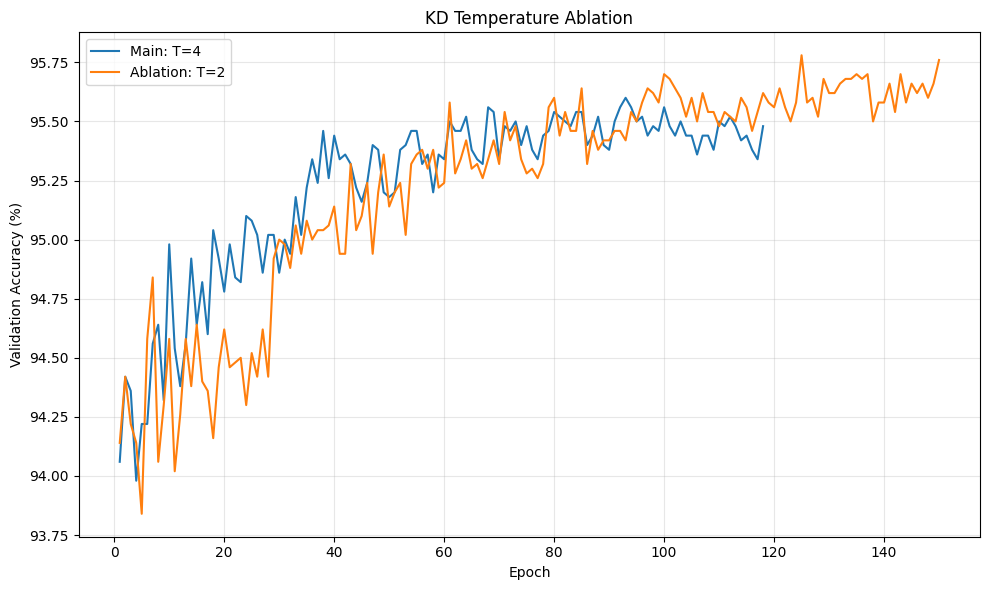

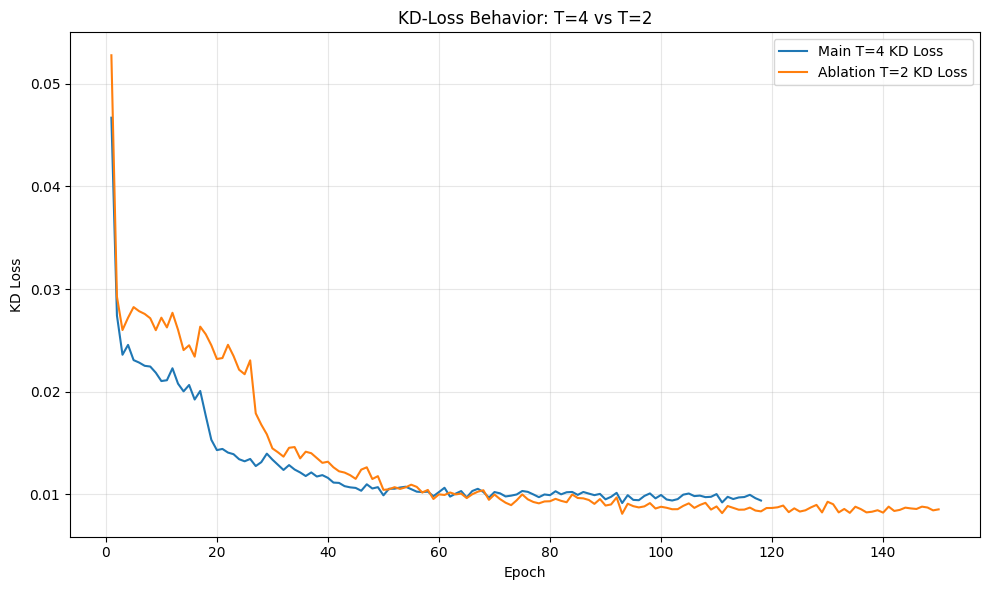

In [58]:
# ============================================================
# CELL 22: Main T=4 vs Ablation T=2 validation curves
# ============================================================

ablation_history_df = pd.read_csv(

    ABLATION_DIR /
    "ablation_T2_history.csv"
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    student_history[
        "epoch"
    ],

    student_history[
        "val_accuracy"
    ],

    label="Main: T=4"
)


plt.plot(
    ablation_history_df[
        "epoch"
    ],

    ablation_history_df[
        "val_accuracy"
    ],

    label="Ablation: T=2"
)


plt.xlabel("Epoch")
plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "KD Temperature Ablation"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "kd_temperature_ablation_accuracy.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    student_history[
        "epoch"
    ],

    student_history[
        "train_kd_loss"
    ],

    label="Main T=4 KD Loss"
)


plt.plot(
    ablation_history_df[
        "epoch"
    ],

    ablation_history_df[
        "train_kd_loss"
    ],

    label="Ablation T=2 KD Loss"
)


plt.xlabel("Epoch")
plt.ylabel("KD Loss")

plt.title(
    "KD-Loss Behavior: T=4 vs T=2"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "kd_temperature_ablation_loss.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [59]:
# ============================================================
# CELL 23: Final ablation test evaluation
# ============================================================

ablation_checkpoint = torch.load(

    ABLATION_PATH,

    map_location="cpu",

    weights_only=False
)


best_ablation_student = (
    build_cifar_resnet18()
)


convert_internal_layers_to_ternary(

    best_ablation_student,

    delta_factor=
        DELTA_FACTOR
)


best_ablation_student.load_state_dict(

    ablation_checkpoint[
        "model_state_dict"
    ]
)


best_ablation_student = (
    best_ablation_student.to(
        DEVICE
    )
)

best_ablation_student.eval()


# ------------------------------------------------------------
# Official test set
# ------------------------------------------------------------

test_dataset = datasets.CIFAR10(

    root=str(
        CIFAR_ROOT
    ),

    train=False,

    download=False,

    transform=
        eval_transform
)


test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


ablation_test_metrics = (
    evaluate_ablation(

        best_ablation_student,

        test_loader
    )
)


ablation_final_sparsity = (
    ternary_sparsity(
        best_ablation_student
    )
)


print("=" * 72)

print(
    "FINAL T=2 ABLATION"
)

print("=" * 72)


print(
    "Best epoch:",
    ablation_checkpoint[
        "epoch"
    ]
)

print(
    "Best validation accuracy:",
    f"{ablation_checkpoint['best_val_accuracy']:.2f}%"
)

print(
    "Official test accuracy:",
    f"{ablation_test_metrics['accuracy']:.2f}%"
)

print(
    "Ternary sparsity:",
    f"{ablation_final_sparsity:.2f}%"
)

FINAL T=2 ABLATION
Best epoch: 125
Best validation accuracy: 95.78%
Official test accuracy: 95.17%
Ternary sparsity: 45.78%


In [60]:
# ============================================================
# CELL 24: Main-vs-ablation results
# ============================================================

ablation_df = pd.DataFrame([

    {
        "Experiment":
            "Main Student",

        "Temperature T":
            MAIN_T,

        "KD Lambda":
            KD_LAMBDA,

        "Delta Factor":
            DELTA_FACTOR,

        "Best Validation Accuracy (%)":
            float(
                student_metrics[
                    "validation_accuracy"
                ]
            ),

        "Test Accuracy (%)":
            student_accuracy,

        "Accuracy Gap vs Teacher (pp)":
            teacher_accuracy
            -
            student_accuracy,

        "Sparsity (%)":
            student_ternary_sparsity,
    },

    {
        "Experiment":
            "Temperature Ablation",

        "Temperature T":
            ABLATION_T,

        "KD Lambda":
            KD_LAMBDA,

        "Delta Factor":
            DELTA_FACTOR,

        "Best Validation Accuracy (%)":
            float(
                ablation_checkpoint[
                    "best_val_accuracy"
                ]
            ),

        "Test Accuracy (%)":
            float(
                ablation_test_metrics[
                    "accuracy"
                ]
            ),

        "Accuracy Gap vs Teacher (pp)":
            teacher_accuracy
            -
            float(
                ablation_test_metrics[
                    "accuracy"
                ]
            ),

        "Sparsity (%)":
            ablation_final_sparsity,
    }
])


display(
    ablation_df
)


ablation_df.to_csv(

    TABLE_DIR /
    "ablation_results.csv",

    index=False
)


with open(
    RESULT_DIR /
    "ablation_results.json",
    "w"
) as f:

    json.dump(
        ablation_df.to_dict(
            orient="records"
        ),
        f,
        indent=4
    )

,Experiment,Temperature T,KD Lambda,Delta Factor,Best Validation Accuracy (%),Test Accuracy (%),Accuracy Gap vs Teacher (pp),Sparsity (%)
0,Main Student,4.0,0.7,0.7,95.60,95.32,0.08,45.528184
1,Temperature Ablation,2.0,0.7,0.7,95.78,95.17,0.23,45.778608


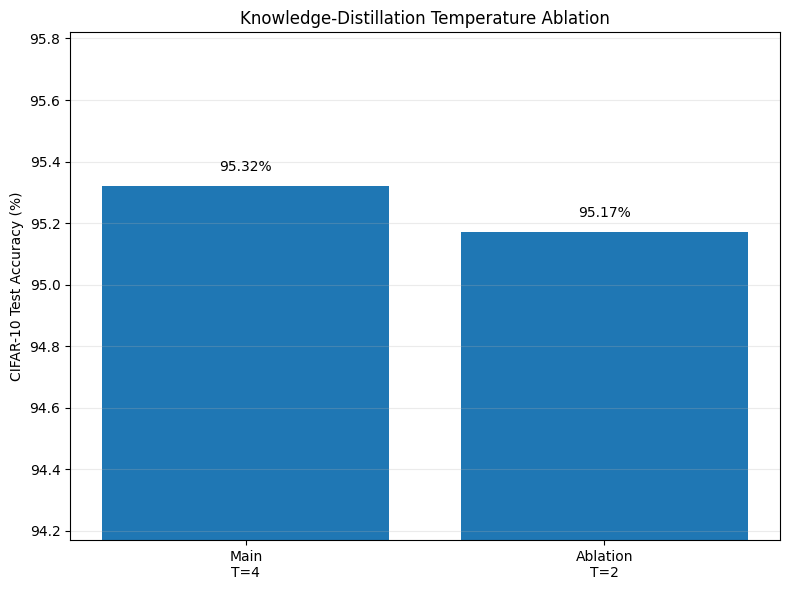

In [61]:
# ============================================================
# CELL 25: Ablation result comparison
# ============================================================

plt.figure(
    figsize=(8, 6)
)


values = ablation_df[
    "Test Accuracy (%)"
].tolist()


bars = plt.bar(

    [
        "Main\nT=4",
        "Ablation\nT=2"
    ],

    values
)


plt.ylabel(
    "CIFAR-10 Test Accuracy (%)"
)

plt.title(
    "Knowledge-Distillation Temperature Ablation"
)

plt.ylim(
    min(values) - 1,
    max(values) + 0.5
)

plt.grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(
    bars,
    values
):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.05,

        f"{value:.2f}%",

        ha="center"
    )


plt.tight_layout()

plt.savefig(
    PLOT_DIR /
    "ablation_final_accuracy.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [78]:
# ============================================================
# CELL 26: Final interpretation and limitations
# ============================================================

student_gap_teacher = (
    teacher_accuracy
    -
    student_accuracy
)

student_gap_baseline = (
    baseline_accuracy
    -
    student_accuracy
)


ablation_accuracy = float(
    ablation_test_metrics[
        "accuracy"
    ]
)


ablation_difference = (
    student_accuracy
    -
    ablation_accuracy
)


discussion = f"""
ATDL Assignment 1
Final Results and Critical Discussion
=====================================

PRIMARY RESULTS
---------------

ResNet34 FP32 Teacher
Test accuracy:
{teacher_accuracy:.2f}%

ResNet18 FP32 Baseline
Test accuracy:
{baseline_accuracy:.2f}%

ResNet18 Ternary + KD + QAT Student
Test accuracy:
{student_accuracy:.2f}%

The ternary student's accuracy gap relative to the teacher is:
{student_gap_teacher:.2f} percentage points.

The accuracy gap relative to the FP32 ResNet18 baseline is:
{student_gap_baseline:.2f} percentage points.

COMPRESSION
-----------

FP32 ResNet18 checkpoint:
{mib(baseline_file_bytes):.2f} MiB

Compact ternary checkpoint:
{mib(student_compact_bytes):.2f} MiB

Actual checkpoint compression:
{actual_student_compression:.2f}x

Ternary-only sparsity:
{student_ternary_sparsity:.2f}%

ABLATION
--------

Main KD configuration:
T = {MAIN_T}
lambda = {KD_LAMBDA}

Ablation:
T = {ABLATION_T}
lambda = {KD_LAMBDA}

Main student test accuracy:
{student_accuracy:.2f}%

T=2 ablation test accuracy:
{ablation_accuracy:.2f}%

Difference:
{ablation_difference:.2f} percentage points.

"""


discussion_path = (
    RESULT_DIR /
    "final_discussion.txt"
)


with open(
    discussion_path,
    "w"
) as f:

    f.write(
        discussion
    )


print(
    discussion
)


ATDL Assignment 1
Final Results and Critical Discussion

PRIMARY RESULTS
---------------

ResNet34 FP32 Teacher
Test accuracy:
95.40%

ResNet18 FP32 Baseline
Test accuracy:
95.49%

ResNet18 Ternary + KD + QAT Student
Test accuracy:
95.32%

The ternary student's accuracy gap relative to the teacher is:
0.08 percentage points.

The accuracy gap relative to the FP32 ResNet18 baseline is:
0.17 percentage points.

COMPRESSION
-----------

FP32 ResNet18 checkpoint:
42.70 MiB

Compact ternary checkpoint:
2.82 MiB

Actual checkpoint compression:
15.13x

Ternary-only sparsity:
45.53%

ABLATION
--------

Main KD configuration:
T = 4.0
lambda = 0.7

Ablation:
T = 2.0
lambda = 0.7

Main student test accuracy:
95.32%

T=2 ablation test accuracy:
95.17%

Difference:
0.15 percentage points.




In [67]:
# ============================================================
# CELL 28: Final artifact inventory
# ============================================================

print(
    "Notebook 4 generated artifacts:\n"
)


for root, dirs, files in os.walk(
    PROJECT_DIR
):

    level = (
        str(root)
        .replace(
            str(PROJECT_DIR),
            ""
        )
        .count(os.sep)
    )

    indent = (
        "    " * level
    )

    print(
        f"{indent}"
        f"{Path(root).name}/"
    )


    subindent = (
        "    "
        *
        (level + 1)
    )


    for filename in sorted(
        files
    ):

        path = (
            Path(root)
            /
            filename
        )

        print(
            f"{subindent}"
            f"{filename} "
            f"({path.stat().st_size / (1024**2):.2f} MiB)"
        )

Notebook 4 generated artifacts:

ATDL_Final_Evaluation/
    results/
        ablation_results.json (0.00 MiB)
        compression_analysis.json (0.00 MiB)
        final_discussion.txt (0.00 MiB)
        final_model_comparison.json (0.00 MiB)
    environment/
        environment.txt (0.00 MiB)
    plots/
        ablation_final_accuracy.png (0.08 MiB)
        accuracy_vs_checkpoint_size.png (0.11 MiB)
        combined_validation_accuracy.png (0.19 MiB)
        combined_validation_loss_convergence.png (0.19 MiB)
        final_accuracy_comparison.png (0.09 MiB)
        fp32_weight_histogram.png (0.08 MiB)
        kd_temperature_ablation_accuracy.png (0.24 MiB)
        kd_temperature_ablation_loss.png (0.14 MiB)
        per_layer_sparsity.png (0.10 MiB)
        student_kd_loss_components.png (0.14 MiB)
        student_qat_sparsity.png (0.08 MiB)
        ternary_code_distribution.png (0.06 MiB)
        ternary_weight_histogram.png (0.07 MiB)
    ablation/
        ablation_T2_history.csv (0.0

In [68]:
# ============================================================
# CELL 29: Export complete Notebook 4 package
# ============================================================

ZIP_BASE = (
    KAGGLE_WORKING_DIR /
    "ATDL_Final_Evaluation"
)


zip_path = shutil.make_archive(

    base_name=str(
        ZIP_BASE
    ),

    format="zip",

    root_dir=str(
        KAGGLE_WORKING_DIR
    ),

    base_dir=
        PROJECT_DIR.name
)


zip_size_mib = (

    os.path.getsize(
        zip_path
    )

    /
    (1024 ** 2)
)


print("=" * 76)
print("NOTEBOOK 4 COMPLETE")
print("=" * 76)


print(
    "\nFinal ZIP:"
)

print(
    zip_path
)


print(
    f"\nZIP size: "
    f"{zip_size_mib:.2f} MiB"
)


print(
    "\nFINAL PRIMARY RESULTS"
)

print(
    f"Teacher        : "
    f"{teacher_accuracy:.2f}%"
)

print(
    f"FP32 Baseline  : "
    f"{baseline_accuracy:.2f}%"
)

print(
    f"Ternary Student: "
    f"{student_accuracy:.2f}%"
)


print(
    f"\nStudent gap vs teacher: "
    f"{student_gap_teacher:.2f} pp"
)


print(
    f"Actual compression: "
    f"{actual_student_compression:.2f}x"
)


print(
    f"Ternary sparsity: "
    f"{student_ternary_sparsity:.2f}%"
)


print(
    "\nABLATION"
)

print(
    f"T={MAIN_T}: "
    f"{student_accuracy:.2f}%"
)

print(
    f"T={ABLATION_T}: "
    f"{ablation_accuracy:.2f}%"
)


print(
    "\nAll report-ready tables, plots, "
    "metrics and ablation results are saved."
)

NOTEBOOK 4 COMPLETE

Final ZIP:
/kaggle/working/ATDL_Final_Evaluation.zip

ZIP size: 40.95 MiB

FINAL PRIMARY RESULTS
Teacher        : 95.40%
FP32 Baseline  : 95.49%
Ternary Student: 95.32%

Student gap vs teacher: 0.08 pp
Actual compression: 15.13x
Ternary sparsity: 45.53%

ABLATION
T=4.0: 95.32%
T=2.0: 95.17%

All report-ready tables, plots, metrics and ablation results are saved.


Using image:
/kaggle/input/datasets/kshitianilkumar/cat-photo/cat.avif

CUSTOM IMAGE INFERENCE RESULTS
ResNet34 FP32 Teacher       : cat           91.09%
ResNet18 FP32 Baseline     : cat           91.22%
ResNet18 Ternary KD + QAT  : cat           92.15%


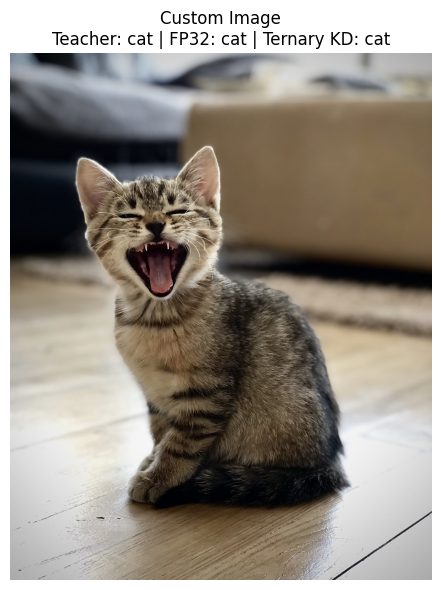

In [75]:
# ============================================================
# CUSTOM IMAGE INFERENCE
# Teacher vs FP32 ResNet18 vs Ternary KD ResNet18
# ============================================================

from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from pathlib import Path

# ------------------------------------------------------------
# 1. Find your uploaded image automatically
# ------------------------------------------------------------

matches = list(Path("/kaggle/input").rglob("cat.avif"))

if not matches:
    raise FileNotFoundError(
        "cat.avif was not found inside /kaggle/input"
    )

IMAGE_PATH = matches[0]

print("Using image:")
print(IMAGE_PATH)


# ------------------------------------------------------------
# 2. CIFAR-10 classes
# ------------------------------------------------------------

CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# ------------------------------------------------------------
# 3. Image preprocessing
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])


# ------------------------------------------------------------
# 4. Load image
# ------------------------------------------------------------

image = Image.open(IMAGE_PATH).convert("RGB")

x = transform(image).unsqueeze(0).to(DEVICE)


# ------------------------------------------------------------
# 5. Use the models already loaded in evaluation.ipynb
# ------------------------------------------------------------

teacher.eval()
baseline.eval()
student.eval()


# ------------------------------------------------------------
# 6. Inference
# ------------------------------------------------------------

with torch.no_grad():

    teacher_logits = teacher(x)
    baseline_logits = baseline(x)
    student_logits = student(x)

    teacher_probs = F.softmax(
        teacher_logits, dim=1
    )[0]

    baseline_probs = F.softmax(
        baseline_logits, dim=1
    )[0]

    student_probs = F.softmax(
        student_logits, dim=1
    )[0]


# ------------------------------------------------------------
# 7. Get predictions
# ------------------------------------------------------------

def get_prediction(probs):

    confidence, index = torch.max(
        probs, dim=0
    )

    return (
        CIFAR10_CLASSES[index.item()],
        confidence.item() * 100
    )


teacher_pred, teacher_conf = get_prediction(
    teacher_probs
)

baseline_pred, baseline_conf = get_prediction(
    baseline_probs
)

student_pred, student_conf = get_prediction(
    student_probs
)


# ------------------------------------------------------------
# 8. Print results
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("CUSTOM IMAGE INFERENCE RESULTS")
print("=" * 65)

print(
    f"ResNet34 FP32 Teacher       : "
    f"{teacher_pred:<12} {teacher_conf:6.2f}%"
)

print(
    f"ResNet18 FP32 Baseline     : "
    f"{baseline_pred:<12} {baseline_conf:6.2f}%"
)

print(
    f"ResNet18 Ternary KD + QAT  : "
    f"{student_pred:<12} {student_conf:6.2f}%"
)

print("=" * 65)


# ------------------------------------------------------------
# 9. Display the original image
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.imshow(image)
plt.axis("off")

plt.title(
    "Custom Image\n"
    f"Teacher: {teacher_pred} | "
    f"FP32: {baseline_pred} | "
    f"Ternary KD: {student_pred}"
)

plt.tight_layout()
plt.show()

Using image:
/kaggle/input/datasets/kshitianilkumar/airplane-photo/airplane.jpg

CUSTOM IMAGE INFERENCE RESULTS
ResNet34 FP32 Teacher       : airplane      90.87%
ResNet18 FP32 Baseline     : airplane      90.13%
ResNet18 Ternary KD + QAT  : airplane      91.21%


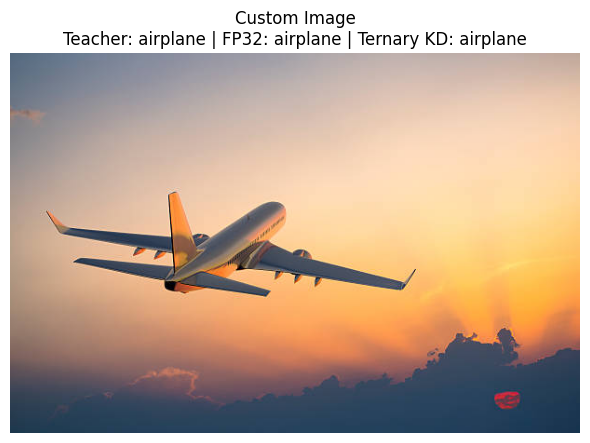

In [76]:
# ============================================================
# CUSTOM IMAGE INFERENCE
# Teacher vs FP32 ResNet18 vs Ternary KD ResNet18
# ============================================================

from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from pathlib import Path

# ------------------------------------------------------------
# 1. Find your uploaded image automatically
# ------------------------------------------------------------

matches = list(Path("/kaggle/input").rglob("airplane.jpg"))

if not matches:
    raise FileNotFoundError(
        "airplane.jpg was not found inside /kaggle/input"
    )

IMAGE_PATH = matches[0]

print("Using image:")
print(IMAGE_PATH)


# ------------------------------------------------------------
# 2. CIFAR-10 classes
# ------------------------------------------------------------

CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# ------------------------------------------------------------
# 3. Image preprocessing
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])


# ------------------------------------------------------------
# 4. Load image
# ------------------------------------------------------------

image = Image.open(IMAGE_PATH).convert("RGB")

x = transform(image).unsqueeze(0).to(DEVICE)


# ------------------------------------------------------------
# 5. Use the models already loaded in evaluation.ipynb
# ------------------------------------------------------------

teacher.eval()
baseline.eval()
student.eval()


# ------------------------------------------------------------
# 6. Inference
# ------------------------------------------------------------

with torch.no_grad():

    teacher_logits = teacher(x)
    baseline_logits = baseline(x)
    student_logits = student(x)

    teacher_probs = F.softmax(
        teacher_logits, dim=1
    )[0]

    baseline_probs = F.softmax(
        baseline_logits, dim=1
    )[0]

    student_probs = F.softmax(
        student_logits, dim=1
    )[0]


# ------------------------------------------------------------
# 7. Get predictions
# ------------------------------------------------------------

def get_prediction(probs):

    confidence, index = torch.max(
        probs, dim=0
    )

    return (
        CIFAR10_CLASSES[index.item()],
        confidence.item() * 100
    )


teacher_pred, teacher_conf = get_prediction(
    teacher_probs
)

baseline_pred, baseline_conf = get_prediction(
    baseline_probs
)

student_pred, student_conf = get_prediction(
    student_probs
)


# ------------------------------------------------------------
# 8. Print results
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("CUSTOM IMAGE INFERENCE RESULTS")
print("=" * 65)

print(
    f"ResNet34 FP32 Teacher       : "
    f"{teacher_pred:<12} {teacher_conf:6.2f}%"
)

print(
    f"ResNet18 FP32 Baseline     : "
    f"{baseline_pred:<12} {baseline_conf:6.2f}%"
)

print(
    f"ResNet18 Ternary KD + QAT  : "
    f"{student_pred:<12} {student_conf:6.2f}%"
)

print("=" * 65)


# ------------------------------------------------------------
# 9. Display the original image
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.imshow(image)
plt.axis("off")

plt.title(
    "Custom Image\n"
    f"Teacher: {teacher_pred} | "
    f"FP32: {baseline_pred} | "
    f"Ternary KD: {student_pred}"
)

plt.tight_layout()
plt.show()